<a href="https://colab.research.google.com/github/tanishparida/Galaxy-Group-Finder-Project/blob/main/Matching_%26_Overlap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from astropy.table import Table

DESI_path   = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/DESI_halos.fits"
bulbul_path = "/content/drive/My Drive/Galaxy Group Finder Project/Data/bulbul_clusters.fits"
balzer_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/balzer_misclassified_clusters.fits"

def fits_to_clean_df(path, one_d_only=True, decode_bytes=True):
    table = Table.read(path, format="fits")
    if one_d_only:
        cols = [c for c in table.colnames if len(table[c].shape) <= 1]
        table = table[cols]
    df = table.to_pandas()
    if decode_bytes:
        for col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].apply(
                    lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x
                )
    return df

# Bulbul
df_bulbul = fits_to_clean_df(bulbul_path)

# Balzer
df_balzer = fits_to_clean_df(balzer_path)
df_balzer["ClusterClass"] = pd.to_numeric(df_balzer["ClusterClass"], errors="coerce")
df_balzer = df_balzer[~df_balzer["ClusterClass"].isin([1, 2])].copy().reset_index(drop=True)

df_DESI = fits_to_clean_df(DESI_path)

print("DESI:", df_DESI.shape)
print("Bulbul:", df_bulbul.shape)
print("Balzer:", df_balzer.shape)

DESI: (2014048, 18)
Bulbul: (12247, 83)
Balzer: (5358, 13)


In [ ]:
import numpy as np
import pandas as pd

# -------------------------------
# 1. Select relevant Balzer columns
# -------------------------------
df_balzer_match = df_balzer[[
    "IAUName",
    "RAJ2000", "DEJ2000", "zBest",
    "ClusterClass",
    "FX300", "CRX300", "ctX300", "LX300",
    "VdispBoot", "lambdaNorm"   # velocity dispersion + richness proxy
]].copy()

# -------------------------------
# 2. Rename to match Bulbul schema
# -------------------------------
df_balzer_match = df_balzer_match.rename(columns={
    "RAJ2000": "RA_XFIT",
    "DEJ2000": "DEC_XFIT",
    "zBest": "BEST_Z"
})

# -------------------------------
# 3. Add missing columns for consistency
# -------------------------------
df_balzer_match["M500"] = np.nan
df_balzer_match["source"] = "balzer"

# -------------------------------
# 4. Add source label to Bulbul
# -------------------------------
df_bulbul = df_bulbul.copy()
df_bulbul["source"] = "bulbul"

# -------------------------------
# 5. Combine catalogs
# -------------------------------
df_xray = pd.concat([df_bulbul, df_balzer_match], ignore_index=True)

print("Combined X-ray catalog shape:", df_xray.shape)
print(df_xray.head())

# -------------------------------
# 6. Save to CSV
# -------------------------------
output_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/xray_combined_catalog.csv"
df_xray.to_csv(output_path, index=False)

print(f"Saved combined catalog to: {output_path}")

Combined X-ray catalog shape: (17605, 92)
                             DETUID                     NAME        RA  \
0  em01_002129_020_ML00014_002_c010  1eRASS J000005.2-383729  0.021730   
1  em01_011174_020_ML00047_002_c010  1eRASS J000021.4-824954  0.089191   
2  em01_002141_020_ML00031_002_c010  1eRASS J000031.0-500903  0.129422   
3  em01_003153_020_ML00092_010_c010  1eRASS J000031.8-630131  0.132712   
4  em01_002135_020_ML00092_002_c010  1eRASS J000045.3-462341  0.189080   

         DEC  RA_XFIT  DEC_XFIT   EXT_LIKE  DET_LIKE_0         EXP  BEST_Z  \
0 -38.624903   0.0214  -38.6250   9.634506   80.586533   94.800003  0.3153   
1 -82.831715   0.0558  -82.8189  14.928127   37.221573  184.199997  0.0891   
2 -50.151013   0.1305  -50.1515   6.975221   46.228764  117.300003  0.0681   
3 -63.025286   0.1265  -63.0225  12.914146   24.212395  139.600006  0.2448   
4 -46.394874   0.1898  -46.3928   4.163312   25.377766  109.500000  0.0925   

   ...                                      

In [ ]:
import pandas as pd
import numpy as np
from astropy.coordinates import SkyCoord, search_around_sky
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.constants import G

# -------------------------------
# Paths
# -------------------------------
desi_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_halos_overlap.csv"
xray_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/xray_combined_catalog.csv"
out_dir = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/"

# -------------------------------
# Cosmology
# -------------------------------
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# -------------------------------
# 1. Load DESI halos
# -------------------------------
df_DESI = pd.read_csv(desi_path).copy().reset_index(drop=True)

print(f"Overlap DESI halos (denominator): {len(df_DESI):,}")

# -------------------------------
# 2. Load X-ray catalog
# -------------------------------
df_xray = pd.read_csv(xray_path)

df_xray = (
    df_xray
    .dropna(subset=["RA_XFIT", "DEC_XFIT", "BEST_Z"])
    .copy()
    .reset_index(drop=True)
)

print(f"Usable X-ray sources: {len(df_xray):,}")

# -------------------------------
# 3. Compute R200c
# -------------------------------
M_halo = df_DESI["M_HALO"].values * u.Msun
z_halo = df_DESI["Z"].values

Hz = cosmo.H(z_halo).to(1 / u.s)
rho_c = 3 * Hz**2 / (8 * np.pi * G)

R200 = (
    (3 * M_halo.to(u.kg))
    / (4 * np.pi * 200 * rho_c)
) ** (1 / 3)

R200_kpc = R200.to(u.kpc).value

DA = cosmo.angular_diameter_distance(z_halo).to(u.kpc).value

theta_R200 = (
    (R200_kpc / DA) * u.rad
).to(u.arcmin)

df_DESI["R200_kpc"] = R200_kpc
df_DESI["theta_R200_arcmin"] = theta_R200.value

# -------------------------------
# 4. Coordinates
# -------------------------------
coords_DESI = SkyCoord(
    ra=df_DESI["RA"].values * u.deg,
    dec=df_DESI["DEC"].values * u.deg
)

coords_xray = SkyCoord(
    ra=df_xray["RA_XFIT"].values * u.deg,
    dec=df_xray["DEC_XFIT"].values * u.deg
)

# -------------------------------
# 5. Pre-search
# -------------------------------
idx_DESI, idx_xray, d2d, _ = search_around_sky(
    coords_DESI,
    coords_xray,
    20 * u.arcmin
)

# -------------------------------
# 6. Cuts
# -------------------------------
within_match_radius = (
    d2d < 1.5 * theta_R200[idx_DESI]
)

delta_z = np.abs(
    df_DESI["Z"].values[idx_DESI]
    - df_xray["BEST_Z"].values[idx_xray]
)

z_cut = delta_z < 0.005

mask = within_match_radius & z_cut

# -------------------------------
# 7. Candidate table
# -------------------------------
candidates = pd.DataFrame({
    "DESI_idx": idx_DESI[mask],
    "xray_idx": idx_xray[mask],
    "sep_arcmin": d2d[mask].to(u.arcmin).value,
    "delta_z": delta_z[mask],
    "R200_arcmin": theta_R200[idx_DESI[mask]].value
})

candidates["offset_r200c"] = (
    candidates["sep_arcmin"]
    / candidates["R200_arcmin"]
)

print(f"Candidate pairs: {len(candidates):,}")

# =====================================================
# TYPE 1 AMBIGUITY
# One DESI halo -> multiple X-ray candidates
# =====================================================

xray_counts_per_halo = (
    candidates
    .groupby("DESI_idx")
    .size()
    .rename("n_xray_candidates")
)

candidates = candidates.merge(
    xray_counts_per_halo,
    left_on="DESI_idx",
    right_index=True
)

candidates["multiple_xray_candidates"] = (
    candidates["n_xray_candidates"] > 1
)

type1_ambiguous = (
    candidates[
        candidates["multiple_xray_candidates"]
    ]
    .copy()
)

# -------------------------------
# 8. Resolve matches
# Keep smallest offset
# -------------------------------
best_matches = (
    candidates
    .sort_values(
        ["DESI_idx", "offset_r200c"]
    )
    .drop_duplicates(
        subset="DESI_idx",
        keep="first"
    )
    .reset_index(drop=True)
)

# =====================================================
# TYPE 2 AMBIGUITY
# Multiple DESI halos -> same X-ray source
# =====================================================

halo_counts_per_xray = (
    best_matches
    .groupby("xray_idx")
    .size()
    .rename("n_halo_candidates")
)

best_matches = best_matches.merge(
    halo_counts_per_xray,
    left_on="xray_idx",
    right_index=True
)

best_matches["multiple_halo_candidates"] = (
    best_matches["n_halo_candidates"] > 1
)

type2_ambiguous = (
    best_matches[
        best_matches["multiple_halo_candidates"]
    ]
    .copy()
)

# -------------------------------
# 9. Build matched dataset
# -------------------------------
df_DESI_pref = df_DESI.add_prefix("DESI_")
df_xray_pref = df_xray.add_prefix("xray_")

matched_full = (
    best_matches
    .merge(
        df_DESI_pref,
        left_on="DESI_idx",
        right_index=True
    )
    .merge(
        df_xray_pref,
        left_on="xray_idx",
        right_index=True
    )
)

# -------------------------------
# 10. Unmatched
# -------------------------------
matched_ids = set(best_matches["DESI_idx"])

df_unmatched = (
    df_DESI.loc[
        ~df_DESI.index.isin(matched_ids)
    ]
    .copy()
    .reset_index(drop=True)
)

# -------------------------------
# 11. Denominator
# -------------------------------
df_denominator = df_DESI.copy()

# -------------------------------
# 12. Save
# -------------------------------
matched_full.to_csv(
    out_dir + "desi_xray_matched.csv",
    index=False
)

df_unmatched.to_csv(
    out_dir + "desi_xray_unmatched.csv",
    index=False
)

df_denominator.to_csv(
    out_dir + "desi_xray_denominator.csv",
    index=False
)

type1_ambiguous.to_csv(
    out_dir + "desi_multiple_xray_candidates.csv",
    index=False
)

type2_ambiguous.to_csv(
    out_dir + "desi_multiple_halo_candidates.csv",
    index=False
)

# -------------------------------
# Summary
# -------------------------------
print("\nSaved:")
print("- matched")
print("- unmatched")
print("- denominator")
print("- desi_multiple_xray_candidates")
print("- desi_multiple_halo_candidates")

print("\nAmbiguity summary:")
print(
    f"Halos with multiple X-ray candidates: "
    f"{type1_ambiguous['DESI_idx'].nunique():,}"
)

print(
    f"X-ray sources with multiple halo matches: "
    f"{type2_ambiguous['xray_idx'].nunique():,}"
)

Overlap DESI halos (denominator): 51,280


/tmp/ipykernel_5218/3080223523.py:30: DtypeWarning: Columns (0,1,11,82,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df_xray = pd.read_csv(xray_path)


Usable X-ray sources: 17,605
Candidate pairs: 895

Saved:
- matched
- unmatched
- denominator
- desi_multiple_xray_candidates
- desi_multiple_halo_candidates

Ambiguity summary:
Halos with multiple X-ray candidates: 18
X-ray sources with multiple halo matches: 122


Loading catalogs...


/tmp/ipykernel_4400/3990671617.py:26: DtypeWarning: Columns (0,1,11,82,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df_bulbul = pd.read_csv(bulbul_path)
/usr/local/lib/python3.12/dist-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


Applying restrictive redshift filter...
Mapping data to HEALPix grid...

 HEALPIX 3D OVERLAP SUMMARY
Redshift Envelope: 0.0145 to 0.5000
Overlap Area: ~769 sq deg
DESI Centrals in Overlap: 51,280
eROSITA Clusters in Overlap: 1,275



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


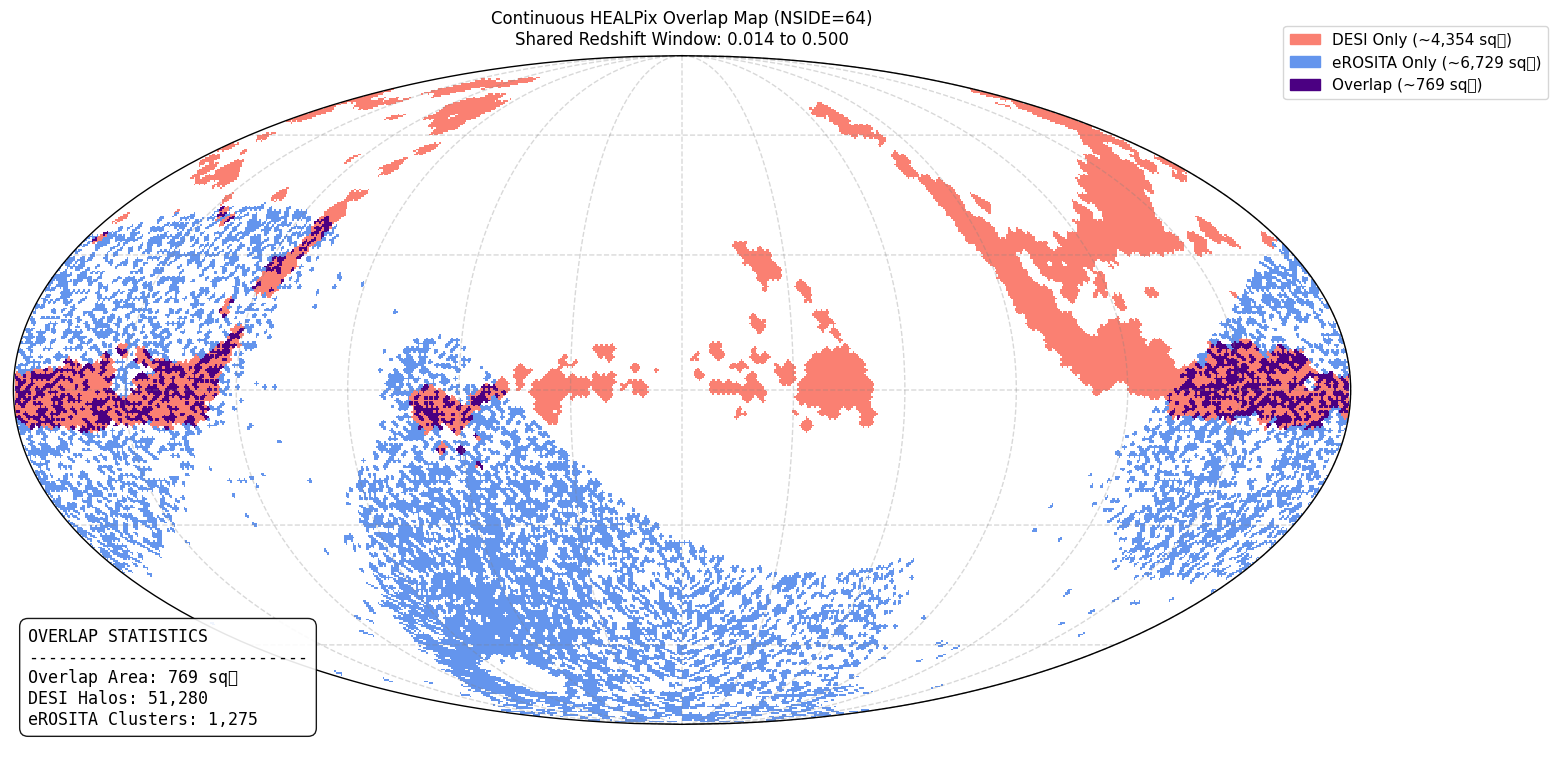

Saved DESI overlap halos to: /content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_halos_overlap.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from astropy.table import Table
import healpy as hp

# ==========================================
# 1. SETUP & LOAD DATA
# ==========================================
print("Loading catalogs...")

# Updated to use the new directories provided
DESI_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/DESI_halos.fits"
bulbul_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/xray_combined_catalog.csv"

# Load DESI
DESI_table = Table.read(DESI_path, hdu=1)
df_DESI = DESI_table.to_pandas()

# Filter: STRICT Centrals Only (IS_SAT == False) AND High Mass (M_HALO > 10^13)
df_DESI = df_DESI[(df_DESI['IS_SAT'] == False) & (df_DESI['M_HALO'] > 1e13)].copy().reset_index(drop=True)

# Load X-ray catalog
df_bulbul = pd.read_csv(bulbul_path)

# ==========================================
# 2. RESTRICTIVE REDSHIFT ENVELOPE
# ==========================================
print("Applying restrictive redshift filter...")

d_z_min, d_z_max = df_DESI['Z'].min(), df_DESI['Z'].max()
b_z_min, b_z_max = df_bulbul['BEST_Z'].min(), df_bulbul['BEST_Z'].max()

shared_z_min = max(d_z_min, b_z_min)
shared_z_max = min(d_z_max, b_z_max)

# Filter catalogs BEFORE calculating the footprint
df_DESI = df_DESI[(df_DESI['Z'] >= shared_z_min) & (df_DESI['Z'] <= shared_z_max)].copy().reset_index(drop=True)
df_bulbul = df_bulbul[(df_bulbul['BEST_Z'] >= shared_z_min) & (df_bulbul['BEST_Z'] <= shared_z_max)].copy().reset_index(drop=True)

# ==========================================
# 3. HEALPIX FOOTPRINT MAP & FILTERING
# ==========================================
print("Mapping data to HEALPix grid...")
nside = 64 # Defines resolution (~0.84 sq deg per pixel)
npix = hp.nside2npix(nside)
pix_area_sqdeg = hp.nside2pixarea(nside, degrees=True)

# Convert RA/DEC to HEALPix Theta/Phi
desi_theta = np.radians(90.0 - df_DESI['DEC'].values)
desi_phi = np.radians(df_DESI['RA'].values)
desi_pixels = hp.ang2pix(nside, desi_theta, desi_phi)

bulbul_theta = np.radians(90.0 - df_bulbul['DEC_XFIT'].values)
bulbul_phi = np.radians(df_bulbul['RA_XFIT'].values)
bulbul_pixels = hp.ang2pix(nside, bulbul_theta, bulbul_phi)

# Create global binary footprints
desi_footprint = np.zeros(npix, dtype=bool)
desi_footprint[desi_pixels] = True

bulbul_footprint = np.zeros(npix, dtype=bool)
bulbul_footprint[bulbul_pixels] = True

# Calculate the precise overlap
overlap_footprint = desi_footprint & bulbul_footprint

# Filter data strictly to objects that land in the overlapping pixels
df_DESI_overlap = df_DESI[overlap_footprint[desi_pixels]].copy().reset_index(drop=True)
df_bulbul_overlap = df_bulbul[overlap_footprint[bulbul_pixels]].copy().reset_index(drop=True)

# Calculate Area Stats
area_desi = np.sum(desi_footprint) * pix_area_sqdeg
area_bulbul = np.sum(bulbul_footprint) * pix_area_sqdeg
area_overlap = np.sum(overlap_footprint) * pix_area_sqdeg

# ==========================================
# 4. PRINT CONSOLE STATISTICS
# ==========================================
print("\n" + "="*50)
print(" HEALPIX 3D OVERLAP SUMMARY")
print("="*50)
print(f"Redshift Envelope: {shared_z_min:.4f} to {shared_z_max:.4f}")
print(f"Overlap Area: ~{area_overlap:,.0f} sq deg")
print(f"DESI Centrals in Overlap: {len(df_DESI_overlap):,}")
print(f"eROSITA Clusters in Overlap: {len(df_bulbul_overlap):,}")
print("="*50 + "\n")

# ==========================================
# 5. GENERATE CONTINUOUS PLOT WITH STATS
# ==========================================
# Create Categorical Map: 0=Bg, 1=DESI, 2=Bulbul, 3=Overlap
combined_map = np.zeros(npix)
combined_map[desi_footprint] = 1
combined_map[bulbul_footprint] = 2
combined_map[overlap_footprint] = 3

cmap = ListedColormap(['white', 'salmon', 'cornflowerblue', 'indigo'])

fig = plt.figure(figsize=(14, 8))

hp.mollview(
    combined_map,
    cmap=cmap,
    cbar=False,
    min=0, max=3,
    title=f"Continuous HEALPix Overlap Map (NSIDE={nside})\nShared Redshift Window: {shared_z_min:.3f} to {shared_z_max:.3f}",
    rot=(0, 0, 0),
    fig=fig.number
)

hp.graticule(color='gray', alpha=0.3, ls='--')

# Build the custom legend
legend_elements = [
    mpatches.Patch(color='salmon', label=f'DESI Only (~{area_desi:,.0f} sq째)'),
    mpatches.Patch(color='cornflowerblue', label=f'eROSITA Only (~{area_bulbul:,.0f} sq째)'),
    mpatches.Patch(color='indigo', label=f'Overlap (~{area_overlap:,.0f} sq째)')
]
plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1.05), fontsize=11)

# Embed the Statistics Dashboard inside the image
stats_text = (
    "OVERLAP STATISTICS\n"
    "----------------------------\n"
    f"Overlap Area: {area_overlap:,.0f} sq째\n"
    f"DESI Halos: {len(df_DESI_overlap):,}\n"
    f"eROSITA Clusters: {len(df_bulbul_overlap):,}"
)

# Place a text box in the bottom left corner of the figure
plt.annotate(
    stats_text,
    xy=(0.02, 0.05), xycoords='figure fraction',
    fontsize=12, fontfamily='monospace',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", alpha=0.9)
)

plt.show()

# ==========================================
# 6. SAVE DESI OVERLAP DATA
# ==========================================
output_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_halos_overlap.csv"

df_DESI_overlap.to_csv(output_path, index=False)

print(f"Saved DESI overlap halos to: {output_path}")

In [ ]:
import pandas as pd
import numpy as np
from astropy.table import Table
import matplotlib.colors as mcolors

# ==========================================
# PATHS
# ==========================================
multi_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_multiple_halo_candidates.csv"
matched_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_xray_matched.csv"
fits_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/DESI_halos.fits"

# ==========================================
# LOAD DATA
# ==========================================
multi = pd.read_csv(multi_path)
matched = pd.read_csv(matched_path)

fits = Table.read(fits_path).to_pandas()

# decode FITS byte strings if needed
for col in fits.columns:
    if fits[col].dtype == object:
        fits[col] = fits[col].apply(
            lambda x: x.decode("utf-8")
            if isinstance(x, (bytes, bytearray))
            else x
        )

# ==========================================
# GET TARGETID FOR EACH HALO
# ==========================================
lookup = matched[
    ["DESI_idx", "DESI_TARGETID"]
].drop_duplicates()

multi = multi.merge(
    lookup,
    on="DESI_idx",
    how="left"
)

# ==========================================
# TARGETID → IGRP
# ==========================================
target_to_igrp = fits[
    ["TARGETID", "IGRP"]
].drop_duplicates()

multi = multi.merge(
    target_to_igrp,
    left_on="DESI_TARGETID",
    right_on="TARGETID",
    how="left"
)

# ==========================================
# COLORS
# ==========================================
base_colors = list(mcolors.TABLEAU_COLORS.values())

rows = []

# ==========================================
# BUILD OUTPUT
# ==========================================
for xray_id, group in multi.groupby("xray_idx"):

    halo_ids = group["DESI_idx"].unique()

    color_map = {
        halo: base_colors[i % len(base_colors)]
        for i, halo in enumerate(halo_ids)
    }

    for _, row in group.iterrows():

        igrp = row["IGRP"]

        if pd.isna(igrp):
            continue

        galaxies = fits[
            fits["IGRP"] == igrp
        ]

        temp = pd.DataFrame({
            "RA": galaxies["RA"],
            "DEC": galaxies["DEC"],
            "color": color_map[row["DESI_idx"]]
        })

        rows.append(temp)

# ==========================================
# FINAL OUTPUT
# ==========================================
legacy_df = pd.concat(
    rows,
    ignore_index=True
)

legacy_df = legacy_df.drop_duplicates()

# ==========================================
# SAVE
# ==========================================
out_path = "/content/drive/MyDrive/Galaxy Group Finder Project/Data/legacy_multiple_halo_view.csv"

legacy_df.to_csv(
    out_path,
    index=False
)

print("Saved:", out_path)
print()
print(legacy_df.head())

Saved: /content/drive/MyDrive/Galaxy Group Finder Project/Data/legacy_multiple_halo_view.csv

          RA       DEC    color
0  52.412289 -2.177555  #1f77b4
1  52.416111 -2.187200  #1f77b4
2  52.423207 -2.196273  #ff7f0e
3  53.227297 -1.739862  #1f77b4
4  53.230187 -1.723459  #1f77b4


In [ ]:
import pandas as pd
import numpy as np
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy import units as u

# ==========================================
# LOAD DATA
# ==========================================

matched = pd.read_csv(
    "/content/drive/MyDrive/Galaxy Group Finder Project/Data/desi_xray_matched.csv"
)

# ==========================================
# FILTERS
# ==========================================

# Bulbul only
matched = matched[
    matched["xray_source"]
    .astype(str)
    .str.lower()
    .str.strip()
    == "bulbul"
]

# Remove ambiguity cases
matched = matched[
    (~matched["multiple_xray_candidates"]) &
    (~matched["multiple_halo_candidates"])
].copy()

print(f"Bulbul clean matched systems: {len(matched):,}")

desi = Table.read(
    "/content/drive/MyDrive/Galaxy Group Finder Project/Data/DESI_halos.fits"
)

desi = desi.to_pandas()

# ==========================================
# OUTPUT STORAGE
# ==========================================

results = []

failed_central_match = 0

# ==========================================
# LOOP OVER MATCHED HALOS
# ==========================================

for _, row in matched.iterrows():

    igrp = row["DESI_IGRP"]

    central_ra = row["DESI_RA"]
    central_dec = row["DESI_DEC"]

    xray_ra = row["xray_RA_XFIT"]
    xray_dec = row["xray_DEC_XFIT"]

    # -------------------------
    # get all halo members
    # -------------------------

    members = desi[
        desi["IGRP"] == igrp
    ].copy()

    if len(members) == 0:
        continue

    # -------------------------
    # locate designated central
    # -------------------------

    central = members[
        (members["RA"] == central_ra) &
        (members["DEC"] == central_dec)
    ]

    if len(central) != 1:

        failed_central_match += 1
        continue

    central_index = central.index[0]

    # -------------------------
    # compute member separations
    # -------------------------

    member_coords = SkyCoord(
        ra=members["RA"].values*u.deg,
        dec=members["DEC"].values*u.deg
    )

    xray_coord = SkyCoord(
        ra=xray_ra*u.deg,
        dec=xray_dec*u.deg
    )

    sep = xray_coord.separation(
        member_coords
    ).arcsec

    members["sep_arcsec"] = sep

    # -------------------------
    # nearest galaxy
    # -------------------------

    closest_index = members[
        "sep_arcsec"
    ].idxmin()

    closest_is_central = (
        closest_index == central_index
    )

    results.append({

        "DESI_IGRP": igrp,
        "xray_idx": row["xray_idx"],
        "n_members": len(members),

        "central_sep_arcsec":
            members.loc[
                central_index,
                "sep_arcsec"
            ],

        "closest_sep_arcsec":
            members.loc[
                closest_index,
                "sep_arcsec"
            ],

        "closest_is_central":
            closest_is_central
    })

# ==========================================
# RESULTS TABLE
# ==========================================

results = pd.DataFrame(results)

results.to_csv(
    "/content/drive/MyDrive/Galaxy Group Finder Project/Data/xray_central_diagnostic.csv",
    index=False
)

# ==========================================
# SUMMARY
# ==========================================

n_total = len(results)

n_central = (
    results["closest_is_central"]
).sum()

n_satellite = (
    ~results["closest_is_central"]
).sum()

print("="*50)
print("X-RAY / CENTRAL DIAGNOSTIC")
print("="*50)

print(
    f"Matched halos checked: "
    f"{n_total:,}"
)

print(
    f"Central lookup failures: "
    f"{failed_central_match:,}"
)

print()

print(
    f"Closest galaxy IS central: "
    f"{n_central:,}"
)

print(
    f"Closest galaxy is satellite: "
    f"{n_satellite:,}"
)

print(
    f"Satellite fraction: "
    f"{100*n_satellite/n_total:.2f}%"
)

print()

print("="*50)
print("EXAMPLE FAILURES")
print("="*50)

display(
    results[
        ~results["closest_is_central"]
    ][[
        "DESI_IGRP",
        "xray_idx",
        "n_members",
        "central_sep_arcsec",
        "closest_sep_arcsec"
    ]]
    .head(10)
)

Bulbul clean matched systems: 374
X-RAY / CENTRAL DIAGNOSTIC
Matched halos checked: 374
Central lookup failures: 0

Closest galaxy IS central: 210
Closest galaxy is satellite: 164
Satellite fraction: 43.85%

EXAMPLE FAILURES


,DESI_IGRP,xray_idx,n_members,central_sep_arcsec,closest_sep_arcsec
0,722,3555,24,154.224680,14.561948
1,2444,3242,4,26.074117,24.957385
2,5620,2980,13,34.907441,34.686367
4,7377,8227,19,280.171351,10.124235
6,13292,3804,73,20.633910,3.469628
8,20382,8142,54,28.535019,19.489856
9,23584,9627,33,13.507234,6.407855
10,28560,8170,78,237.234442,14.684977
11,34692,3679,14,17.059562,9.642234
17,52693,8811,6,37.320717,37.007018


  sat_bin    N  fraction       err
0     0–2   78  0.884615  0.036175
1    3–10   82  0.524390  0.055150
2   11–25   63  0.476190  0.062923
3     26+  151  0.450331  0.040488


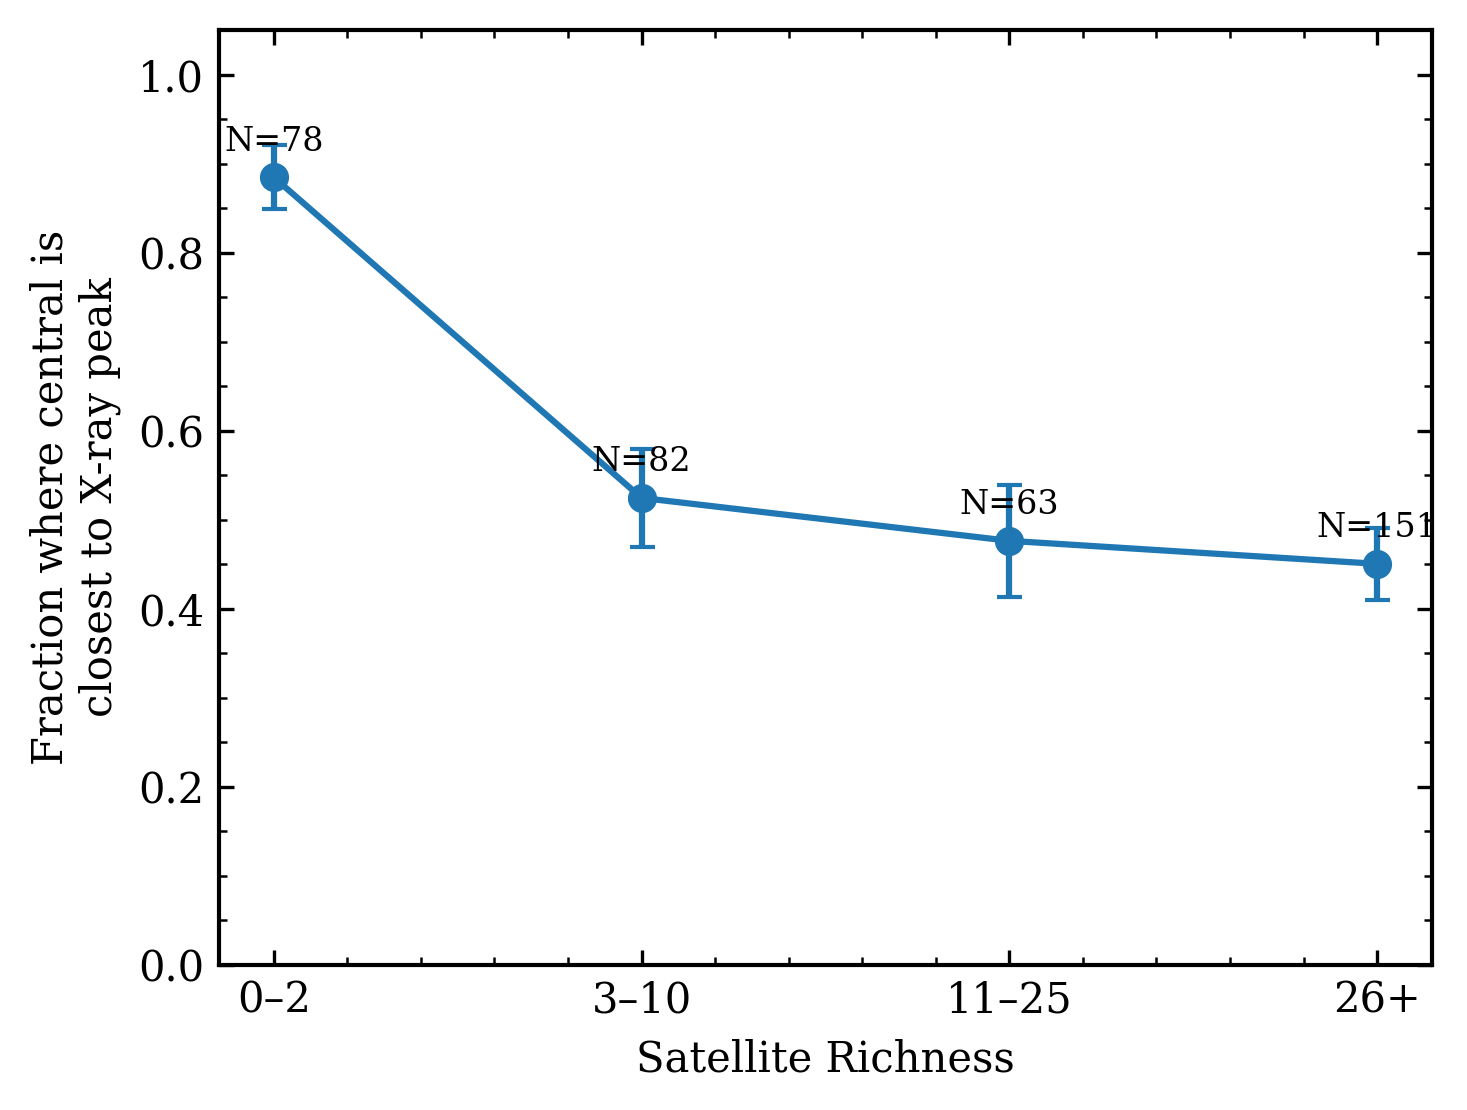

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# LOAD DIAGNOSTIC RESULTS
# ==========================================

df = pd.read_csv(
    "/content/drive/MyDrive/Galaxy Group Finder Project/Data/xray_central_diagnostic.csv"
)

# ==========================================
# SATELLITE BINS
# ==========================================

sat_bins = [0,2,10,25,np.inf]

sat_labels = [
    "0–2",
    "3–10",
    "11–25",
    "26+"
]

df["sat_bin"] = pd.cut(
    df["n_members"]-1,      # subtract central
    bins=sat_bins,
    labels=sat_labels,
    include_lowest=True
)

# ==========================================
# COMPUTE FRACTIONS
# ==========================================

summary=[]

for sat in sat_labels:

    s=df[
        df["sat_bin"]==sat
    ]

    N=len(s)

    if N==0:
        continue

    n_rank1=s["closest_is_central"].sum()

    frac=n_rank1/N

    # binomial uncertainty
    err=np.sqrt(
        frac*(1-frac)/N
    )

    summary.append({
        "sat_bin":sat,
        "N":N,
        "fraction":frac,
        "err":err
    })

summary=pd.DataFrame(summary)

print(summary)

# ==========================================
# PUBLICATION STYLE
# ==========================================

plt.rcParams.update({
    "figure.dpi":300,
    "font.family":"serif",
    "font.serif":["Times New Roman","DejaVu Serif"],
    "font.size":10,
    "axes.linewidth":1,
    "xtick.direction":"in",
    "ytick.direction":"in",
    "xtick.top":True,
    "ytick.right":True,
    "legend.frameon":False
})

# ==========================================
# PLOT
# ==========================================

fig,ax=plt.subplots(
    figsize=(5,3.8)
)

x=np.arange(len(summary))

ax.errorbar(
    x,
    summary["fraction"],
    yerr=summary["err"],
    marker="o",
    linewidth=1.5,
    capsize=3
)

# sample size labels
for i,row in summary.iterrows():

    ax.text(
        x[i],
        row["fraction"]+.03,
        f"N={row['N']}",
        ha="center",
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(
    summary["sat_bin"]
)

ax.set_ylim(0,1.05)

ax.set_xlabel(
    "Satellite Richness"
)

ax.set_ylabel(
    "Fraction where central is\nclosest to X-ray peak"
)

ax.minorticks_on()

plt.tight_layout()
plt.show()